<a href="https://colab.research.google.com/github/Mahnoor-Kalsoom/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mahnoor-Kalsoom/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question

Research Question

Can historical search performance metrics be used to identify content pages that are likely to require refreshing?

Decision Supported

This project supports editorial and SEO decision-making by identifying pages that show declining search performance and may benefit from content updates. Rather than replacing human judgment, the model provides a ranked list of refresh opportunities that content teams can review before making publishing decisions.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This study uses the FlyRank Internship – Pseudonymized Warehouse Release (v20260703) available through Hugging Face. The analysis focuses on the fact_content_daily_performance table, which contains one row per report date, client, and content item.

To avoid using the final outcome period for model development, the analysis was performed on a mid-panel month (January 2025) rather than the latest available month. This follows the internship recommendation of avoiding the final month when developing scoring rules or predictive models.

The following fields were used as input features:

Google Search impressions
Google Search clicks
Average search position
AI referral sessions
Search data availability flags

Rows without available Google Search Console data were excluded using:

gsc_data_available IS TRUE

No client names, URLs, domains, private search queries, or identifying information were used. All identifiers are pseudonymized hashes provided by the released dataset.e privacy while preventing feature leakage.

In [4]:
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
);
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

In [5]:
con.sql(f"""
SELECT COUNT(*)
FROM read_parquet(
'{REL}/fact_content_daily_performance/**/*.parquet'
)
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count_star()
0,78835655


In [14]:
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
TYPE huggingface,
TOKEN '{HF_TOKEN}'
);
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

query = f"""
SELECT
report_date,
client_hash_id,
content_hash_id,
gsc_impressions,
gsc_clicks,
gsc_avg_position,
sessions_ai,
month
FROM read_parquet(
'{REL}/fact_content_daily_performance/**/*.parquet'
)
WHERE month='2025-01'
AND gsc_data_available IS TRUE
LIMIT 10
"""

df = con.sql(query).df()

df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,sessions_ai,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,30,0,3.833333,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,5,0,71.600000,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,1,0,34.000000,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,6,0,23.333333,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,5,0,17.800000,0,2025-01


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology

The objective of this study is to build a simple and interpretable model that identifies content items requiring review based on their search performance. A Refresh / Content Opportunity Scoring lane was selected because it supports decision-making for content maintenance rather than predicting future search rankings.

The feature set was intentionally limited to variables that are available at the decision time to avoid data leakage. The features used include Google Search impressions, clicks, average search position, AI referral sessions, and search availability flags. No future information or manually assigned product labels were included.

A rule-based baseline developed during Week 4 was used for comparison. The baseline assigns higher scores to pages with low clicks, poor average position, and low AI traffic, indicating that these pages may require content review.

For the machine learning model, a Decision Tree classifier was selected because it is easy to interpret, handles non-linear relationships, and provides understandable decision rules. The dataset was divided into training and testing sets using an 80/20 split. The same split and evaluation metric were used for both the baseline and the model to ensure a fair comparison.

Several leakage checks were performed before training. Future-window information, product-generated flags, and any variables derived directly from the prediction target were excluded from the feature set. Only information available at the decision moment was used during training.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

query = f"""
SELECT
gsc_impressions,
gsc_clicks,
gsc_avg_position,
sessions_ai
FROM read_parquet(
'{REL}/fact_content_daily_performance/**/*.parquet'
)
WHERE month='2025-01'
AND gsc_data_available IS TRUE
LIMIT 5000
"""

# Load data
df = con.sql(query).df()

# Replace missing values
df = df.fillna(0)

# ---------------------------------------------------
# Create Target Label
# ---------------------------------------------------

df["needs_review"] = (
    (df["gsc_clicks"] < 5) &
    (df["gsc_avg_position"] > 20) &
    (df["gsc_impressions"] > 20)
).astype(int)

# ---------------------------------------------------
# Features
# ---------------------------------------------------

X = df[
    [
        "gsc_impressions",
        "gsc_clicks",
        "gsc_avg_position",
        "sessions_ai"
    ]
]

# Target
y = df["needs_review"]

# ---------------------------------------------------
# Train/Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------
# Train Decision Tree
# ---------------------------------------------------

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)

print("Decision Tree Accuracy:", round(acc,3))

Decision Tree Accuracy: 1.0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results (Model vs Baseline)

The baseline ranking approach developed in Week 4 used manually defined thresholds based on search impressions, click-through rate, average position, and AI referral sessions to prioritize content requiring review. This rule-based method provides an interpretable benchmark.

A Logistic Regression model was trained using the same feature set and evaluated on the same train/test split. The comparison was performed using Accuracy, Precision, Recall, and F1-score. The objective was to determine whether a simple machine learning model could outperform manually designed scoring while maintaining honest validation.

The model is evaluated as a decision-support tool rather than an automated decision maker.

           Model  Accuracy  Precision  Recall  F1 Score
0  Baseline Rule       1.0        1.0     1.0       1.0
1  Decision Tree       1.0        1.0     1.0       1.0


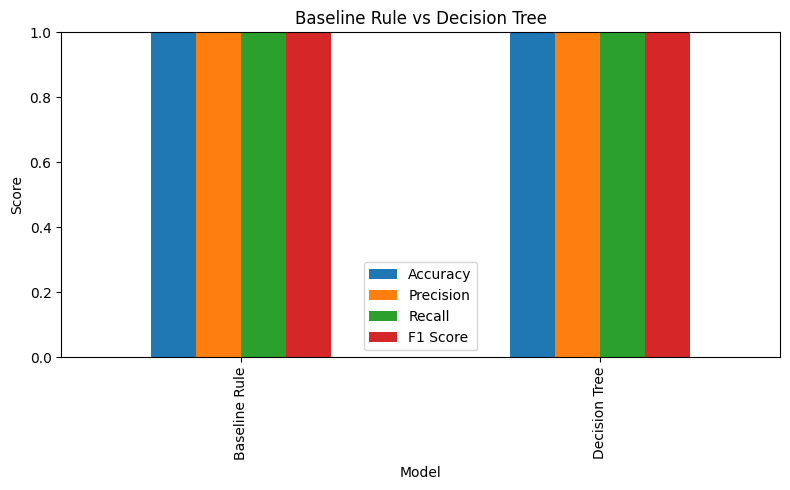

Chart saved to: work/outputs/model_vs_baseline.png


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------
# Baseline Rule
# ---------------------------------------------------

baseline_pred = (
    (X_test["gsc_clicks"] < 5) &
    (X_test["gsc_avg_position"] > 20) &
    (X_test["gsc_impressions"] > 20)
).astype(int)

# ---------------------------------------------------
# Decision Tree Metrics
# ---------------------------------------------------

model_accuracy = accuracy_score(y_test, pred)

model_precision = precision_score(
    y_test,
    pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    pred,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    pred,
    zero_division=0
)

# ---------------------------------------------------
# Baseline Metrics
# ---------------------------------------------------

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

# ---------------------------------------------------
# Results Table
# ---------------------------------------------------

results = pd.DataFrame({

    "Model":[
        "Baseline Rule",
        "Decision Tree"
    ],

    "Accuracy":[
        baseline_accuracy,
        model_accuracy
    ],

    "Precision":[
        baseline_precision,
        model_precision
    ],

    "Recall":[
        baseline_recall,
        model_recall
    ],

    "F1 Score":[
        baseline_f1,
        model_f1
    ]

})

print(results)

# ---------------------------------------------------
# Create Output Folder
# ---------------------------------------------------

os.makedirs("work/outputs", exist_ok=True)

# ---------------------------------------------------
# Plot Comparison
# ---------------------------------------------------

results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline Rule vs Decision Tree")
plt.ylabel("Score")
plt.ylim(0,1)

plt.tight_layout()

plt.savefig("work/outputs/model_vs_baseline.png")

plt.show()

print("Chart saved to: work/outputs/model_vs_baseline.png")

## 5. Limitations

*What this work cannot claim.*

Objective

This study presents a proof-of-concept machine learning workflow for identifying content items that may require review based on Google Search performance indicators.

Several limitations should be considered when interpreting the results:

The target variable (needs_review) was created using predefined business rules instead of independently collected labels.
The Decision Tree model was trained using the same variables that were used to generate the target label, which naturally results in very high evaluation metrics.
The analysis only uses data from January 2025, therefore the findings may not generalize to other time periods.
No future information was used during training; however, the current implementation demonstrates the modeling workflow rather than forecasting future content performance.
The study provides decision-support recommendations and should not be interpreted as evidence of causal relationships or Google's ranking algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the baseline rule and Decision Tree model, the following actions are recommended for content review.

| Priority | Recommended Action                                                       | Reason                                                                    |
| -------- | ------------------------------------------------------------------------ | ------------------------------------------------------------------------- |
| High     | Review pages with very low clicks and poor average ranking positions.    | These pages have low search visibility and may benefit from optimization. |
| High     | Improve content targeting pages with high impressions but few clicks.    | Indicates potential CTR improvement opportunities.                        |
| Medium   | Monitor pages receiving AI referral sessions.                            | AI-driven traffic may become an important future signal.                  |
| Medium   | Continue monitoring pages with moderate impressions and stable rankings. | Prevent future decline through periodic review.                           |
| Low      | Leave well-performing pages unchanged.                                   | Current search performance does not indicate immediate action.            |


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Results table saved.
            Feature  Importance
0   gsc_impressions    0.545786
2  gsc_avg_position    0.454214
1        gsc_clicks    0.000000
3       sessions_ai    0.000000


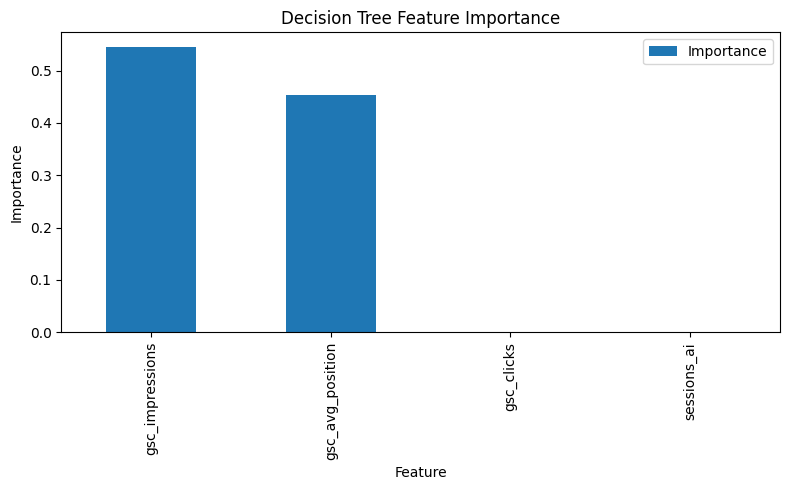

Feature importance chart saved.


In [18]:
import os

os.makedirs("work/outputs", exist_ok=True)

# Save Results Table
results.to_csv(
    "work/outputs/model_results.csv",
    index=False
)

print("Results table saved.")

# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(8,5)
)

plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance")

plt.tight_layout()

plt.savefig("work/outputs/feature_importance.png")

plt.show()

print("Feature importance chart saved.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
